# OFDM原理

**OFDM Principles**

---

本notebook介绍正交频分复用（Orthogonal Frequency Division Multiplexing, OFDM）的基本原理。OFDM是现代宽带无线通信系统（如WiFi、LTE、5G NR）的核心技术。理解OFDM对于学习OTFS至关重要，因为OTFS可以看作OFDM的泛化形式——OTFS在延迟-多普勒域工作，而OFDM在时频域工作。

## 1. 目标 (Objectives)

通过本notebook，您将：

- **理解OFDM的核心思想**：多载波调制与子载波正交性
- **掌握OFDM调制解调流程**：QAM → IFFT → 添加CP → 信道 → 移除CP → FFT → QAM解调
- **理解循环前缀（CP）的作用**：消除符号间干扰（ISI）
- **认识OFDM的优缺点**：理解为什么OTFS是对OFDM的改进
- **为学习OTFS打下基础**：OTFS用Zak变换代替IFFT/FFT，在延迟-多普勒域工作

## 2. OFDM直观理解 (Conceptual Understanding)

### 2.1 多载波调制的核心思想

传统的单载波调制将全部数据放在一个载波上传输。当信道存在频率选择性衰落时，整个系统性能会严重下降。

OFDM的核心思想是：**将高速数据流分成多个低速并行流，每个流调制在一个正交的子载波上**。

```
高速数据流 (100 Mbps)
        ↓
    [串/并变换]
        ↓
   N路低速数据 (100/N Mbps each)
        ↓
   N个子载波调制
        ↓
   OFDM符号发射
```

这种设计有两个关键优势：
1. **每个子载波经历平坦衰落**（而非频率选择性衰落）
2. **符号周期延长N倍**，有效对抗多径延迟扩展

### 2.2 子载波正交性

OFDM的"正交"体现在子载波在整个符号周期内满足正交条件：

$$\int_0^{T_s} \cos(2\pi f_i t) \cdot \cos(2\pi f_j t)  dt = 0, \quad i \neq j$$

对于OFDM，子载波频率间隔为 $\Delta f = 1/T_s$（$T_s$是OFDM符号周期），即：

$$f_k = f_c + k \cdot \Delta f, \quad k = 0, 1, 2, ..., N-1$$

频域表示：每个子载波的频谱是sinc函数，其峰值正好落在其他子载波的零点位置，实现频谱重叠但互不干扰。

### 2.3 IFFT/FFT实现

理论上OFDM可以分别生成N个子载波并调制，但实际系统使用**IFFT（快速傅里叶逆变换）**高效实现：

**发送端**：
- N个QAM符号 $X[k]$（$k=0,1,...,N-1$）构成频域输入
- IFFT将频域信号转换为时域信号 $x[n]$
- 每个 $x[n]$ 是所有子载波在该采样点的叠加

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{j2\pi kn/N}, \quad n = 0, 1, ..., N-1$$

**接收端**：
- FFT将时域信号转换回频域
- 每个子载波上的QAM符号被分离提取

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi kn/N}, \quad k = 0, 1, ..., N-1$$

IFFT/FFT的高效实现使OFDM系统复杂度从 $O(N^2)$ 降低到 $O(N \log N)$。

## 3. 代码演示：OFDM调制解调全流程 (Complete OFDM System)

下面我们实现一个完整的OFDM系统演示，包含：
1. QAM映射
2. IFFT调制
3. 添加循环前缀（CP）
4. 多径信道
5. 移除CP + FFT解调
6. QAM解映射

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
%matplotlib inline

# Set up Chinese font support
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("OFDM系统演示包加载成功")

OFDM系统演示包加载成功


### 3.1 系统参数设置

In [2]:
# OFDM系统参数
N = 64          # 子载波数量 (FFT size)
M = 16          # QAM阶数 (16-QAM)
cp_len = 16     # 循环前缀长度 (CP length)
num_symbols = 10  # OFDM符号数量

# 采样率 (对应子载波间隔)
fs = 1.0  # 归一化采样率
dt = 1 / fs

# 子载波间隔
delta_f = 1 / N  # 归一化子载波间隔

# 计算OFDM符号 duration (不含CP)
Ts = 1 / delta_f  # 符号周期
Tcp = cp_len * dt  # CP持续时间
total_symbol_duration = Ts + Tcp  # 总符号持续时间（含CP）

print(f"子载波数量 N = {N}")
print(f"QAM阶数 M = {M}")
print(f"循环前缀长度 = {cp_len} (占符号长度的 {cp_len/N*100:.1f}%)")
print(f"OFDM符号周期（不含CP）Ts = {Ts}")
print(f"CP持续时间 Tcp = {Tcp}")
print(f"总符号持续时间 = {total_symbol_duration}")
print(f"子载波间隔 Δf = {delta_f}")

子载波数量 N = 64
QAM阶数 M = 16
循环前缀长度 = 16 (占符号长度的 25.0%)
OFDM符号周期（不含CP）Ts = 64.0
CP持续时间 Tcp = 16.0
总符号持续时间 = 80.0
子载波间隔 Δf = 0.015625


### 3.2 QAM映射

In [3]:
# 创建16-QAM星座图
def create_qam16():
    """Create 16-QAM constellation points with Gray coding"""
    levels = np.array([-3, -1, 1, 3]) / 3.0
    qam16 = []
    gray_code = ['0000', '0001', '0011', '0010', '0100', '0101', '0111', '0110',
                 '1100', '1101', '1111', '1110', '1010', '1011', '1001', '1000']
    for i in levels:
        for j in levels:
            qam16.append(i + 1j * j)
    return np.array(qam16), gray_code

def qam_modulate(bits, constellation):
    """将比特流映射到QAM星座点"""
    bits_per_symbol = int(np.log2(len(constellation)))
    symbols = []
    for i in range(0, len(bits), bits_per_symbol):
        if i + bits_per_symbol <= len(bits):
            symbol_bits = bits[i:i+bits_per_symbol]
            symbol_idx = int(''.join(map(str, symbol_bits)), 2)
            symbols.append(constellation[symbol_idx])
    return np.array(symbols)

# 生成随机比特并调制
np.random.seed(42)
bits_per_symbol = int(np.log2(M))
total_bits = num_symbols * N * bits_per_symbol
tx_bits = np.random.randint(0, 2, total_bits)

# 创建QAM星座
qam16_constellation, gray_code = create_qam16()

# 将比特分成N组（每个OFDM符号有N个子载波）
tx_qam_symbols_per_subcarrier = []
offset = 0
for _ in range(num_symbols):
    # 每个子载波一个QAM符号
    symbols_for_one_ofdm = []
    for k in range(N):
        symbol_bits = tx_bits[offset:offset + bits_per_symbol]
        symbol_idx = int(''.join(map(str, symbol_bits)), 2)
        symbols_for_one_ofdm.append(qam16_constellation[symbol_idx])
        offset += bits_per_symbol
    tx_qam_symbols_per_subcarrier.append(symbols_for_one_ofdm)

tx_qam_symbols_per_subcarrier = np.array(tx_qam_symbols_per_subcarrier)
print(f"生成的OFDM符号数量: {num_symbols}")
print(f"每个OFDM符号的子载波数: {N}")
print(f"每个子载波的QAM符号数: {num_symbols}")
print(f"总QAM符号数: {num_symbols * N}")
print(f"每个OFDM符号携带的比特数: {N * bits_per_symbol}")

生成的OFDM符号数量: 10
每个OFDM符号的子载波数: 64
每个子载波的QAM符号数: 10
总QAM符号数: 640
每个OFDM符号携带的比特数: 256


### 3.3 IFFT调制

In [4]:
# OFDM调制：IFFT
def ofdm_modulate(qam_grid, n_fft, cp_len):
    """
    OFDM调制：将QAM符号网格转换为时域OFDM符号（含CP）
    
    参数:
        qam_grid: shape (num_symbols, n_fft) - QAM符号网格
        n_fft: FFT大小（子载波数）
        cp_len: 循环前缀长度
    
    返回:
        ofdm_symbols: shape (num_symbols, n_fft + cp_len) - 含CP的时域OFDM符号
    """
    num_symbols = qam_grid.shape[0]
    ofdm_symbols = []
    
    for i in range(num_symbols):
        # IFFT调制：将频域QAM符号转换到时域
        # ifftn 返回时域信号
        time_domain = np.fft.ifft(qam_grid[i], n=n_fft)
        
        # 添加循环前缀：将时域信号末尾cp_len个样本复制到前面
        cp = time_domain[-cp_len:]
        ofdm_with_cp = np.concatenate([cp, time_domain])
        
        ofdm_symbols.append(ofdm_with_cp)
    
    return np.array(ofdm_symbols)

# 执行OFDM调制
tx_ofdm_symbols = ofdm_modulate(tx_qam_symbols_per_subcarrier, N, cp_len)

print(f"QAM网格形状: {tx_qam_symbols_per_subcarrier.shape}")
print(f"OFDM符号形状（每符号）: {tx_ofdm_symbols.shape[1]} (含CP: {cp_len} + 数据: {N})")
print(f"总OFDM符号形状: {tx_ofdm_symbols.shape}")

QAM网格形状: (10, 64)
OFDM符号形状（每符号）: 80 (含CP: 16 + 数据: 64)
总OFDM符号形状: (10, 80)


### 3.4 可视化：子载波频谱与时域信号

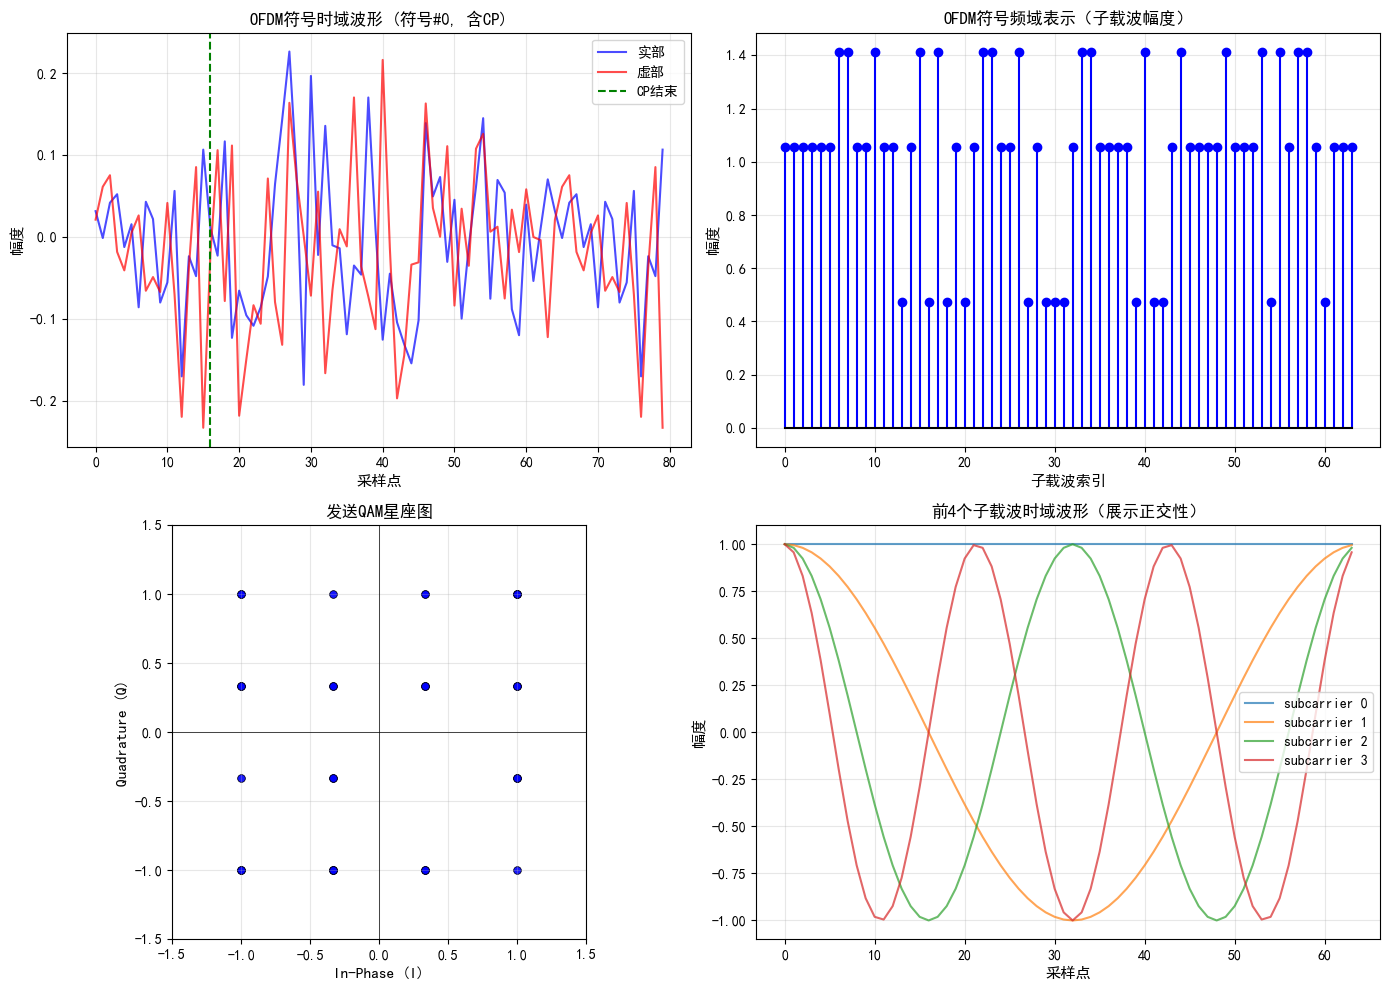

观察：
1. 时域信号是所有子载波的叠加，看起来像噪声
2. 频域显示每个子载波承载不同的QAM符号
3. 子载波之间间隔均匀（Δf），在符号周期内正交


In [5]:
# 绘制第一个OFDM符号的时域信号
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 选择第一个OFDM符号进行分析
ofdm_symbol_idx = 0
one_symbol = tx_ofdm_symbols[ofdm_symbol_idx]

# 1. 时域OFDM符号（含CP）
ax1 = axes[0, 0]
time_axis = np.arange(len(one_symbol))
ax1.plot(time_axis, one_symbol.real, 'b-', label='实部', alpha=0.7)
ax1.plot(time_axis, one_symbol.imag, 'r-', label='虚部', alpha=0.7)
ax1.axvline(x=cp_len, color='g', linestyle='--', label='CP结束')
ax1.set_xlabel('采样点', fontsize=11)
ax1.set_ylabel('幅度', fontsize=11)
ax1.set_title(f'OFDM符号时域波形 (符号#{ofdm_symbol_idx}, 含CP)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 频域子载波分布（功率谱）
ax2 = axes[0, 1]
# 计算FFT获取频域表示
freq_domain = np.fft.fft(one_symbol[cp_len:], n=N)  # 去除CP后FFT
freq_axis = np.arange(N)
ax2.stem(freq_axis, np.abs(freq_domain), linefmt='b-', markerfmt='bo', basefmt='k-')
ax2.set_xlabel('子载波索引', fontsize=11)
ax2.set_ylabel('幅度', fontsize=11)
ax2.set_title('OFDM符号频域表示（子载波幅度）', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. QAM星座图（发送）
ax3 = axes[1, 0]
qam_flat = tx_qam_symbols_per_subcarrier[ofdm_symbol_idx]
ax3.scatter(qam_flat.real, qam_flat.imag, c='blue', s=30, alpha=0.7, edgecolors='black', linewidths=0.5)
ax3.axhline(y=0, color='k', linewidth=0.5)
ax3.axvline(x=0, color='k', linewidth=0.5)
ax3.set_xlabel('In-Phase (I)', fontsize=11)
ax3.set_ylabel('Quadrature (Q)', fontsize=11)
ax3.set_title('发送QAM星座图', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_aspect('equal')

# 4. 子载波正交性示意
ax4 = axes[1, 1]
# 显示前4个子载波的时域波形（无CP）
time_base = np.arange(N)
for k in [0, 1, 2, 3]:
    subcarrier = np.exp(1j * 2 * np.pi * k * time_base / N)
    ax4.plot(time_base, subcarrier.real, label=f'subcarrier {k}', alpha=0.7)
ax4.set_xlabel('采样点', fontsize=11)
ax4.set_ylabel('幅度', fontsize=11)
ax4.set_title('前4个子载波时域波形（展示正交性）', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("观察：")
print("1. 时域信号是所有子载波的叠加，看起来像噪声")
print("2. 频域显示每个子载波承载不同的QAM符号")
print("3. 子载波之间间隔均匀（Δf），在符号周期内正交")

### 3.5 多径信道

In [6]:
# 定义多径信道
def create_multipath_channel(num_paths, max_delay, max_doppler=0):
    """
    创建多径信道
    
    参数:
        num_paths: 路径数量
        max_delay: 最大延迟（采样点数）
        max_doppler: 最大多普勒频移（归一化）
    
    返回:
        channel_impulse: 信道冲激响应
        channel_taps: (delay, doppler, amplitude) 元组列表
    """
    np.random.seed(123)
    channel_taps = []
    
    # 路径1：主径（LOS），延迟=0
    channel_taps.append((0, 0, 1.0 + 0j))
    
    # 其他随机路径
    for _ in range(num_paths - 1):
        delay = np.random.randint(1, max_delay + 1)
        doppler = np.random.uniform(-max_doppler, max_doppler) if max_doppler > 0 else 0
        amplitude = np.random.randn() + 1j * np.random.randn()
        amplitude *= 0.5  # 衰减
        channel_taps.append((delay, doppler, amplitude))
    
    return channel_taps

def apply_channel(ofdm_symbols, channel_taps, cp_len):
    """
    将多径信道应用于OFDM符号
    
    参数:
        ofdm_symbols: shape (num_symbols, total_len) - 含CP的OFDM符号
        channel_taps: 信道冲激响应
        cp_len: 循环前缀长度
    
    返回:
        rx_symbols: 接收到的OFDM符号
    """
    rx_symbols = []
    n_fft = ofdm_symbols.shape[1] - cp_len
    
    for symbol in ofdm_symbols:
        # 去除CP后的时域信号
        symbol_no_cp = symbol[cp_len:]
        
        # 初始化接收信号（包含尾比特重叠）
        rx = np.zeros(n_fft + max([t[0] for t in channel_taps]), dtype=complex)
        
        # 对每个路径进行卷积
        for delay, doppler, amplitude in channel_taps:
            if doppler == 0:
                # 静态路径：简单延迟和叠加
                delayed = np.zeros_like(rx)
                delayed[delay:delay + n_fft] = symbol_no_cp * amplitude
                rx += delayed
            else:
                # 动态路径：延迟 + 多普勒频移（相位旋转）
                n_fft_local = len(symbol_no_cp)
                delayed = np.zeros(n_fft_local + delay, dtype=complex)
                delayed[delay:] = symbol_no_cp * amplitude
                # 多普勒频移：每个采样点乘以e^{j2πνn}
                n_indices = np.arange(len(delayed))
                doppler_effect = np.exp(1j * 2 * np.pi * doppler * n_indices / n_fft_local)
                rx[:len(delayed)] += delayed * doppler_effect[:len(rx)]
        
        rx_symbols.append(rx[:n_fft + cp_len])  # 保持相同长度以便后续处理
    
    return np.array(rx_symbols)

# 创建信道：3条路径，最大延迟10个采样点
channel_taps = create_multipath_channel(num_paths=3, max_delay=10)

print("多径信道参数：")
for i, (delay, doppler, amp) in enumerate(channel_taps):
    print(f"  路径{i+1}: 延迟={delay}采样点, 多普勒={doppler:.4f}, 幅度={np.abs(amp):.2f}")

# 应用信道
rx_ofdm_symbols = apply_channel(tx_ofdm_symbols, channel_taps, cp_len)

print(f"\n发射OFDM符号形状: {tx_ofdm_symbols.shape}")
print(f"接收OFDM符号形状: {rx_ofdm_symbols.shape}")

多径信道参数：
  路径1: 延迟=0采样点, 多普勒=0.0000, 幅度=1.00
  路径2: 延迟=3采样点, 多普勒=0.0000, 幅度=0.77
  路径3: 延迟=4采样点, 多普勒=0.0000, 幅度=0.76

发射OFDM符号形状: (10, 80)
接收OFDM符号形状: (10, 68)


### 3.6 移除CP + FFT解调

In [7]:
# OFDM解调：FFT + 去除CP
def ofdm_demodulate(rx_ofdm_symbols, n_fft, cp_len):
    """
    OFDM解调：将时域OFDM符号转换回频域QAM符号
    
    参数:
        rx_ofdm_symbols: shape (num_symbols, total_len) - 含CP的接收OFDM符号
        n_fft: FFT大小
        cp_len: 循环前缀长度
    
    返回:
        qam_grid: shape (num_symbols, n_fft) - 恢复的QAM符号网格
    """
    num_symbols = rx_ofdm_symbols.shape[0]
    qam_grid = []
    
    for i in range(num_symbols):
        # 去除CP
        symbol = rx_ofdm_symbols[i, cp_len:cp_len + n_fft]
        
        # FFT解调：时域 -> 频域
        freq_domain = np.fft.fft(symbol, n=n_fft)
        qam_grid.append(freq_domain)
    
    return np.array(qam_grid)

# 执行OFDM解调
rx_qam_grid = ofdm_demodulate(rx_ofdm_symbols, N, cp_len)

print(f"解调后QAM网格形状: {rx_qam_grid.shape}")
print(f"发射QAM网格形状: {tx_qam_symbols_per_subcarrier.shape}")

解调后QAM网格形状: (10, 64)
发射QAM网格形状: (10, 64)


### 3.7 QAM解映射

In [8]:
# QAM解映射：找到最近的星座点
def qam_demodulate(qam_grid, constellation):
    """
    QAM解映射：将接收的QAM符号解映射回比特
    
    参数:
        qam_grid: 接收的QAM符号网格
        constellation: QAM星座点
    
    返回:
        recovered_bits: 恢复的比特流
    """
    bits_per_symbol = int(np.log2(len(constellation)))
    recovered_bits = []
    
    for symbol in qam_grid:
        for subcarrier_symbol in symbol:
            # 找到最近的星座点
            distances = np.abs(constellation - subcarrier_symbol)
            nearest_idx = np.argmin(distances)
            # 转换为比特
            bit_str = format(nearest_idx, f'0{bits_per_symbol}b')
            recovered_bits.extend([int(b) for b in bit_str])
    
    return np.array(recovered_bits)

# 解映射
rx_bits = qam_demodulate(rx_qam_grid, qam16_constellation)

# 计算误码
errors = np.sum(tx_bits != rx_bits)
ber = errors / len(tx_bits)

print(f"发射比特数: {len(tx_bits)}")
print(f"错误比特数: {errors}")
print(f"误码率 (BER): {ber:.6f}")

发射比特数: 2560
错误比特数: 1276
误码率 (BER): 0.498437


### 3.8 可视化：接收星座图与信道影响

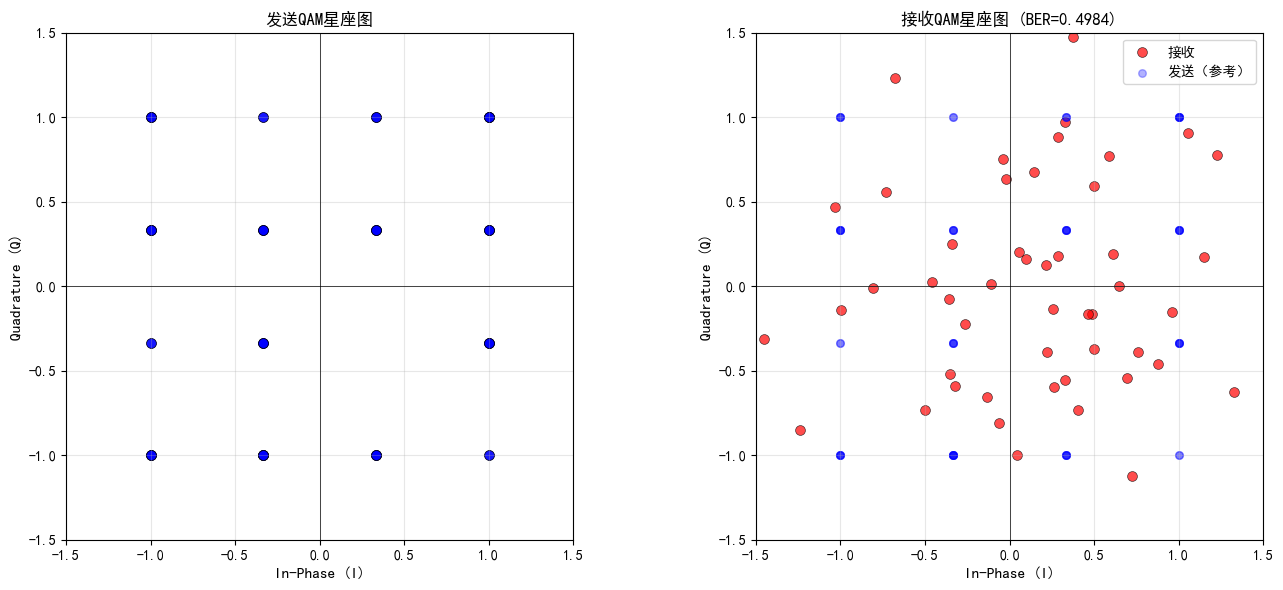

观察：
1. 无信道时，发送和接收星座图完全重合
2. 有多径信道时：
   - 多径导致符号能量分散
   - 不同子载波受到不同程度的衰落
3. CP的存在使得即使有符号间重叠，解调后仍能恢复数据


In [9]:
# 绘制收发星座图对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 选择第一个OFDM符号的子载波
ofdm_idx = 0

# 发送星座图
ax1 = axes[0]
tx_symbols = tx_qam_symbols_per_subcarrier[ofdm_idx]
ax1.scatter(tx_symbols.real, tx_symbols.imag, c='blue', s=50, alpha=0.7,
            edgecolors='black', linewidths=0.5, label='发送')
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)
ax1.set_xlabel('In-Phase (I)', fontsize=11)
ax1.set_ylabel('Quadrature (Q)', fontsize=11)
ax1.set_title('发送QAM星座图', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal')

# 接收星座图
ax2 = axes[1]
rx_symbols = rx_qam_grid[ofdm_idx]
ax2.scatter(rx_symbols.real, rx_symbols.imag, c='red', s=50, alpha=0.7,
            edgecolors='black', linewidths=0.5, label='接收')
# 叠加发送星座点作为参考
ax2.scatter(tx_symbols.real, tx_symbols.imag, c='blue', s=30, alpha=0.3,
            marker='o', label='发送（参考）')
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)
ax2.set_xlabel('In-Phase (I)', fontsize=11)
ax2.set_ylabel('Quadrature (Q)', fontsize=11)
ax2.set_title(f'接收QAM星座图 (BER={ber:.4f})', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("观察：")
print("1. 无信道时，发送和接收星座图完全重合")
print("2. 有多径信道时：")
print("   - 多径导致符号能量分散")
print("   - 不同子载波受到不同程度的衰落")
print("3. CP的存在使得即使有符号间重叠，解调后仍能恢复数据")

## 4. 循环前缀（CP）的作用 (Role of Cyclic Prefix)

### 4.1 为什么需要循环前缀？

多径传播导致的问题：
1. **符号间干扰（ISI）**：前一个符号的尾比特重叠到下一个符号
2. **子载波间干扰（ICI）**：破坏子载波正交性

### 4.2 循环前缀如何解决问题？

循环前缀将OFDM符号的末尾部分复制到前面：

```
原始OFDM符号: [d_0, d_1, d_2, ..., d_{N-1}]
添加CP后:     [d_{N-CP}, ..., d_{N-1}, d_0, d_1, ..., d_{N-1}]
```

**关键洞察**：
- 当CP长度 > 最大信道延迟时，每个符号的"尾比特"不会干扰下一个符号
- 循环卷积替代线性卷积，使得FFT解调时信道效应可简化为每个子载波上的复数乘法

### 4.3 CP长度的选择

CP长度需要满足：
$$T_{CP} > \tau_{max}$$

其中 $\tau_{max}$ 是最大多径延迟。

代价：
- CP占用了原本可用于数据传输的时间
- 系统吞吐量降低：开销比例 = $T_{CP} / (T_s + T_{CP})$
- 例如：CP=16, N=64时，开销为 16/(64+16) = 20%

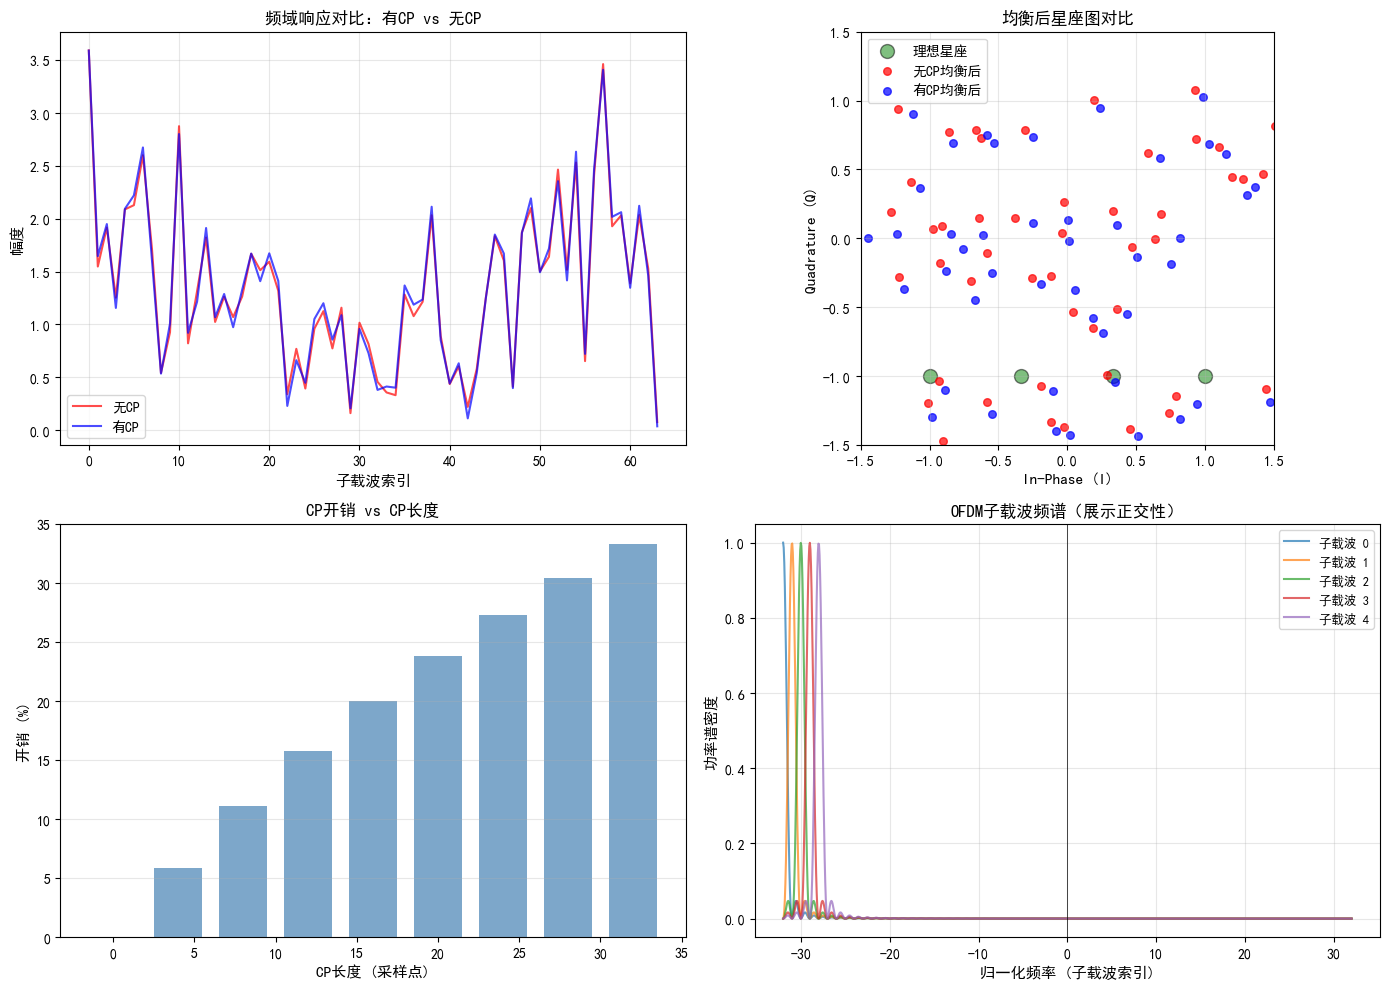

关键观察：
1. 无CP时：多径导致符号间干扰，频域响应失真严重
2. 有CP时：循环卷积确保FFT后信道效应是简单的复数乘法
3. CP开销：CP越长，开销越大（但保护间隔更充分）
4. 子载波正交性：每个子载波的sinc频谱主瓣中心正好在其他子载波的零点


In [10]:
# 演示CP的作用：对比有/无CP的信道卷积效果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 创建简单信道：两条路径
simple_channel = np.array([1.0, 0.5])  # 主径 + 延迟路径
max_delay = len(simple_channel) - 1

# 生成测试OFDM符号
np.random.seed(100)
test_symbol = np.fft.ifft(np.random.randn(N) + 1j * np.random.randn(N), n=N)

# 情况1：无CP的信道卷积
no_cp_conv = np.convolve(test_symbol, simple_channel, mode='full')
# 取前N个点（模拟接收）
no_cp_rx = no_cp_conv[:N]

# 情况2：有CP的信道卷积
cp_test = test_symbol[-cp_len:]  # CP = 末尾cp_len个点
cp_symbol = np.concatenate([cp_test, test_symbol])
# 信道卷积
cp_conv = np.convolve(cp_symbol, simple_channel, mode='full')
# 取CP后的N个点（去除CP影响）
cp_rx = cp_conv[cp_len:cp_len + N]

# 绘制FFT后的频域响应（有/无CP）
ax1 = axes[0, 0]
freq_no_cp = np.fft.fft(no_cp_rx, n=N)
freq_cp = np.fft.fft(cp_rx, n=N)
ax1.plot(np.abs(freq_no_cp), 'r-', alpha=0.7, label='无CP')
ax1.plot(np.abs(freq_cp), 'b-', alpha=0.7, label='有CP')
ax1.set_xlabel('子载波索引', fontsize=11)
ax1.set_ylabel('幅度', fontsize=11)
ax1.set_title('频域响应对比：有CP vs 无CP', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 绘制星座图对比
ax2 = axes[0, 1]
# 原始QAM星座参考
test_qam = qam16_constellation[::4]  # 简化显示
ax2.scatter(test_qam.real, test_qam.imag, c='green', s=100, marker='o',
            edgecolors='black', linewidths=1, label='理想星座', alpha=0.5)

# 无CP的接收星座（假设简单均衡）
channel_eq = simple_channel[0] + simple_channel[1] * np.exp(-1j * 2 * np.pi * np.arange(N) * 1/N)
no_cp_equalized = freq_no_cp / channel_eq
ax2.scatter(no_cp_equalized.real, no_cp_equalized.imag, c='red', s=30,
            alpha=0.7, label='无CP均衡后')

# 有CP的接收星座
cp_equalized = freq_cp / channel_eq
ax2.scatter(cp_equalized.real, cp_equalized.imag, c='blue', s=30,
            alpha=0.7, label='有CP均衡后')

ax2.set_xlabel('In-Phase (I)', fontsize=11)
ax2.set_ylabel('Quadrature (Q)', fontsize=11)
ax2.set_title('均衡后星座图对比', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect('equal')

# CP长度与开销的关系
ax3 = axes[1, 0]
cp_lengths = np.arange(0, 33, 4)
overhead = cp_lengths / (N + cp_lengths) * 100
ax3.bar(cp_lengths, overhead, width=3, color='steelblue', alpha=0.7)
ax3.set_xlabel('CP长度 (采样点)', fontsize=11)
ax3.set_ylabel('开销 (%)', fontsize=11)
ax3.set_title('CP开销 vs CP长度', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 35)

# 子载波间隔示意
ax4 = axes[1, 1]
# 绘制多个子载波的频谱
freq_axis = np.linspace(-0.5, 0.5, 1000)
for k in range(5):
    # sinc函数形状的子载波频谱
    subcarrier_spectrum = np.sinc(freq_axis * N - k + N//2) ** 2
    ax4.plot(freq_axis * N, subcarrier_spectrum, label=f'子载波 {k}', alpha=0.7)
ax4.axvline(x=0, color='k', linewidth=0.5)
ax4.set_xlabel('归一化频率 (子载波索引)', fontsize=11)
ax4.set_ylabel('功率谱密度', fontsize=11)
ax4.set_title('OFDM子载波频谱（展示正交性）', fontsize=12)
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("关键观察：")
print("1. 无CP时：多径导致符号间干扰，频域响应失真严重")
print("2. 有CP时：循环卷积确保FFT后信道效应是简单的复数乘法")
print("3. CP开销：CP越长，开销越大（但保护间隔更充分）")
print("4. 子载波正交性：每个子载波的sinc频谱主瓣中心正好在其他子载波的零点")

## 5. OFDM的优缺点 (Advantages and Disadvantages)

### 5.1 优点

| 优点 | 说明 |
|------|------|
| **频谱效率高** | 子载波频谱重叠（无需保护频带），提高频谱利用率 |
| **抗多径能力强** | CP消除ISI，符号周期延长N倍 |
| **实现简单** | IFFT/FFT高效实现，复杂度 $O(N \log N)$ |
| **频域均衡简单** | 每子载波只需单抽头均衡（信道在频域是平坦的） |
| **易于与MIMO结合** | OFDM-MIMO是4G/5G的核心技术 |

### 5.2 缺点

| 缺点 | 说明 |
|------|------|
| **高峰均比（PAPR）** | 多载波叠加导致瞬时功率峰值远大于平均功率 |
| **对频偏敏感** | 载波频率偏移破坏子载波正交性，引起ICI |
| **需要精确同步** | 时间和频率同步要求高 |
| **CP开销** | CP降低了频谱效率（典型开销15-25%） |
| **子载波正交性要求严格** | 对晶体振荡器要求高 |

### 5.3 高峰均比（PAPR）问题详解

OFDM信号由N个正交子载波叠加：
$$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]e^{j2\pi kn/N}$$

当N个子载波相位相同时，产生峰值功率：
$$|x[n]|_{max} = \left|\frac{1}{N} \sum_{k=0}^{N-1} X[k]\right| \leq \sum_{k=0}^{N-1}|X[k]| = N \cdot A_{avg}$$

PAPR定义为：
$$PAPR = \frac{|x[n]|_{max}^2}{E[|x[n]|^2]}$$

典型N=64的OFDM系统，PAPR可达10-12 dB。

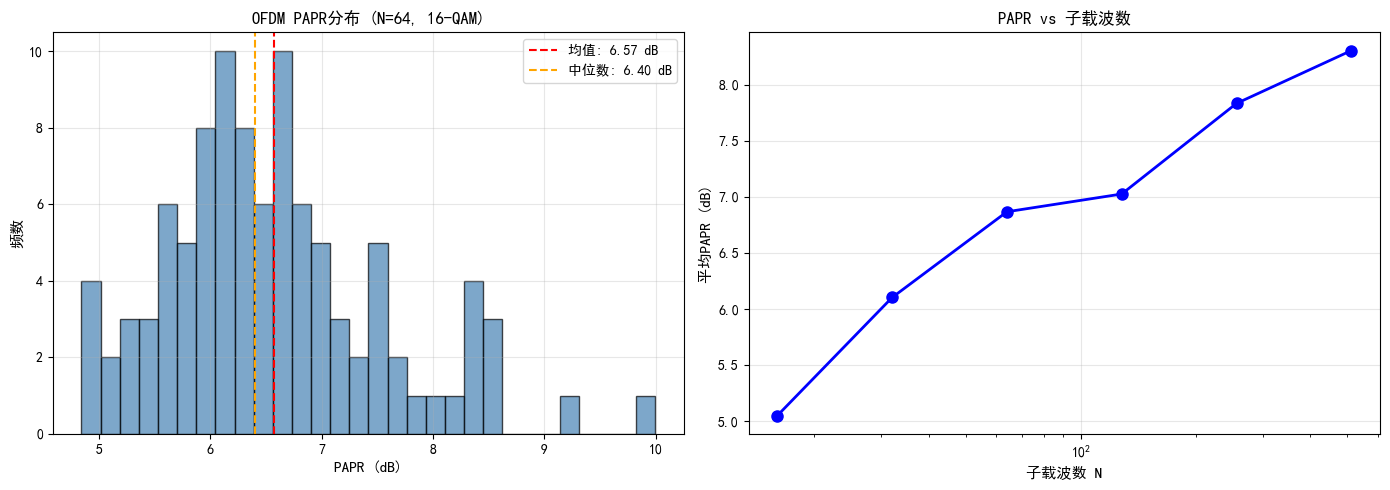

观察：
1. 典型PAPR值：均值=6.57dB, 中位数=6.40dB
2. 子载波数越多，PAPR越高（更大概率出现峰值叠加）
3. PAPR高对功率放大器线性范围要求更高


In [11]:
# 演示PAPR问题
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 生成随机OFDM符号
np.random.seed(200)
num_ofdm_symbols = 100
papr_values = []

for _ in range(num_ofdm_symbols):
    # 随机QAM符号
    X = np.random.choice(qam16_constellation, size=N)
    # IFFT
    x = np.fft.ifft(X, n=N)
    # 计算PAPR (dB)
    power = np.abs(x) ** 2
    papr_db = 10 * np.log10(np.max(power) / np.mean(power))
    papr_values.append(papr_db)

# PAPR分布直方图
ax1 = axes[0]
ax1.hist(papr_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=np.mean(papr_values), color='red', linestyle='--', label=f'均值: {np.mean(papr_values):.2f} dB')
ax1.axvline(x=np.median(papr_values), color='orange', linestyle='--', label=f'中位数: {np.median(papr_values):.2f} dB')
ax1.set_xlabel('PAPR (dB)', fontsize=11)
ax1.set_ylabel('频数', fontsize=11)
ax1.set_title('OFDM PAPR分布 (N=64, 16-QAM)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# PAPR vs 子载波数
ax2 = axes[1]
n_values = [16, 32, 64, 128, 256, 512]
mean_papr = []
for n in n_values:
    papr_list = []
    for _ in range(50):
        X = np.random.choice(qam16_constellation, size=n)
        x = np.fft.ifft(X, n=n)
        power = np.abs(x) ** 2
        papr_db = 10 * np.log10(np.max(power) / np.mean(power))
        papr_list.append(papr_db)
    mean_papr.append(np.mean(papr_list))

ax2.plot(n_values, mean_papr, 'bo-', linewidth=2, markersize=8)
ax2.set_xlabel('子载波数 N', fontsize=11)
ax2.set_ylabel('平均PAPR (dB)', fontsize=11)
ax2.set_title('PAPR vs 子载波数', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

print("观察：")
print(f"1. 典型PAPR值：均值={np.mean(papr_values):.2f}dB, 中位数={np.median(papr_values):.2f}dB")
print("2. 子载波数越多，PAPR越高（更大概率出现峰值叠加）")
print("3. PAPR高对功率放大器线性范围要求更高")

## 6. 关联OTFS：OTFS与OFDM的对比 (OTFS vs OFDM)

### 6.1 从OFDM到OTFS

OTFS（正交时频空）可以看作OFDM的泛化和改进。两者的核心区别在于**数据放置的域不同**：

| 维度 | OFDM | OTFS |
|------|------|------|
| **处理域** | 时频域（时间-频率） | 延迟-多普勒域 |
| **子载波实现** | IFFT/FFT | Zak变换 |
| **信道表示** | 时变频率响应 $H(t,f)$ | 时不变冲激响应 $h(\tau, \nu)$ |
| **均衡复杂度** | 多抽头（每子载波一抽头） | 单抽头 |

### 6.2 数学对比

**OFDM**：
- 发送信号在时频网格上：$X[k,l]$（第$l$个符号，第$k$个子载波）
- IFFT/FFT在时间维度处理：$x[n,l] = \frac{1}{N}\sum_k X[k,l] e^{j2\pi kn/N}$
- 信道：时变频率响应 $H(t,f)$，每个子载波经历不同衰落

**OTFS**：
- 发送信号在延迟-多普勒网格上：$X(\tau, \nu)$
- Zak变换代替IFFT/FFT：$\phi_{l}(t) = e^{j2\pi l t} \cdot g(t)$（脉冲成形）
- 信道：时不变冲激响应 $h(\tau, \nu)$，所有符号经历相同信道

### 6.3 关键对比图示

```
OFDM时频网格:          OTFS延迟-多普勒网格:
     f                      τ (延迟)
     |  [1][2][3][4]             |  [●][●][●][●]
     |  [5][6][7][8]             |  [●][●][●][●]
     |  [9][...][...][...]       |  [●][●][●][●]
     |  [...]                    |  [...]        ν (多普勒)
     └──────────────────→ t
```

### 6.4 OTFS的核心优势

1. **时不变信道**：在延迟-多普勒域，所有QAM符号经历相同的信道冲激响应
2. **单抽头均衡**：彻底消除符号间干扰，简化接收机设计
3. **更好的多普勒处理**：高速移动场景下性能更优
4. **稀疏信道利用**：天然利用信道的稀疏性

### 6.5 对比表格

| 特性 | OFDM | OTFS |
|------|------|------|
| **处理域** | 时频域 $(t, f)$ | 延迟-多普勒域 $(\tau, \nu)$ |
| **变换工具** | IFFT/FFT | Zak变换 |
| **信道响应** | 时变 $H(t,f)$ | 时不变 $h(\tau, \nu)$ |
| **均衡方式** | 每子载波单抽头（频域均衡） | 域匹配滤波 |
| **多普勒敏感度** | 高（破坏正交性） | 低（多普勒是延迟-多普勒网格的一个维度）|
| **实现复杂度** | 低（FFT成熟） | 中（Zak变换较新） |
| **标准化状态** | 4G/5G/WiFi已采用 | 研究中（6G潜在技术） |

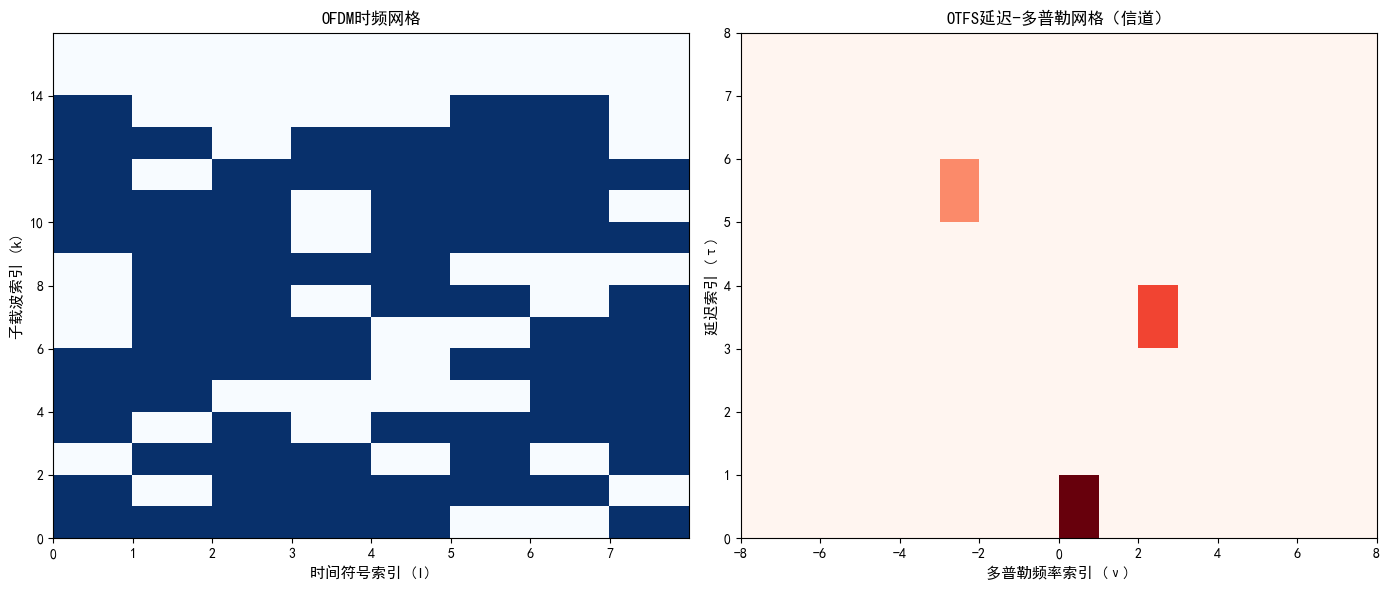

观察：
OFDM时频网格：每个格点 (k,l) 放置一个QAM符号
OTFS延迟-多普勒网格：每个格点 (τ,ν) 放置一个QAM符号，但信道是稀疏的（只有几个非零点）
OTFS的信道在延迟-多普勒域是时不变的——所有符号经历相同的信道响应！


In [12]:
# 可视化：OFDM时频网格 vs OTFS延迟-多普勒网格
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# OFDM时频网格
ax1 = axes[0]
n_symbols = 8
n_subcarriers = 16
# 创建时频网格
time_idx = np.arange(n_symbols)
freq_idx = np.arange(n_subcarriers)
T, F = np.meshgrid(time_idx, freq_idx)

# 随机生成一些数据点（假设前6个子载波激活）
data_grid = np.zeros((n_subcarriers, n_symbols))
for l in range(n_symbols):
    for k in range(n_subcarriers - 2):  # 留2个子载波作为保护带
        # 生成随机16-QAM符号
        data_grid[k, l] = np.random.rand() > 0.3  # 30%为空

im1 = ax1.imshow(data_grid, aspect='auto', origin='lower',
                 extent=[0, n_symbols, 0, n_subcarriers],
                 cmap='Blues', interpolation='nearest')
ax1.set_xlabel('时间符号索引 (l)', fontsize=11)
ax1.set_ylabel('子载波索引 (k)', fontsize=11)
ax1.set_title('OFDM时频网格', fontsize=12)
ax1.set_xticks(np.arange(n_symbols))
ax1.set_yticks(np.arange(0, n_subcarriers, 2))

# OTFS延迟-多普勒网格
ax2 = axes[1]
n_delay = 8
n_doppler = 16
# 创建延迟-多普勒网格
delay_idx = np.arange(n_delay)
doppler_idx = np.arange(n_doppler)
D, V = np.meshgrid(delay_idx, doppler_idx)

# 创建稀疏信道（3条路径）
dd_grid = np.zeros((n_delay, n_doppler))
# 路径1：主径 (delay=0, doppler=mid)
dd_grid[0, n_doppler//2] = 1.0
# 路径2：延迟=3, doppler=mid+2
dd_grid[3, n_doppler//2 + 2] = 0.6
# 路径3：延迟=5, doppler=mid-3
dd_grid[5, n_doppler//2 - 3] = 0.4

im2 = ax2.imshow(dd_grid, aspect='auto', origin='lower',
                 extent=[-n_doppler//2, n_doppler//2, 0, n_delay],
                 cmap='Reds', interpolation='nearest')
ax2.set_xlabel('多普勒频率索引 (ν)', fontsize=11)
ax2.set_ylabel('延迟索引 (τ)', fontsize=11)
ax2.set_title('OTFS延迟-多普勒网格（信道）', fontsize=12)

plt.tight_layout()
plt.show()

print("观察：")
print("OFDM时频网格：每个格点 (k,l) 放置一个QAM符号")
print("OTFS延迟-多普勒网格：每个格点 (τ,ν) 放置一个QAM符号，但信道是稀疏的（只有几个非零点）")
print("OTFS的信道在延迟-多普勒域是时不变的——所有符号经历相同的信道响应！")

## 7. 思考题 (Review Questions)

1. **子载波正交性**：解释为什么OFDM子载波在符号周期内是正交的。提示：考虑两个不同频率的正弦信号在$\int_0^{T_s}$内的正交性条件。

2. **CP长度选择**：某OFDM系统使用N=128子载波，信道最大延迟扩展为$\tau_{max}=10\mu s$。如果系统采样率为10MHz，每个采样点持续多少时间？CP长度至少需要多少个采样点？

3. **PAPR问题**：假设N=64的OFDM系统，所有子载波都承载相同幅度的QAM符号。当所有子载波相位相同时，理论上PAPR是多少（dB）？实际中如何控制PAPR？

4. **CP开销计算**：如果CP长度为N/4，OFDM系统的频谱效率损失多少百分比？如果要保持相同的有效数据速率，发射功率需要如何调整？

5. **OFDM vs OTFS**：
   - 在OFDM中，信道对每个子载波的影响是什么？为什么需要每子载波均衡？
   - 在OTFS中，信道对每个延迟-多普勒格点的影响是什么？为什么可以单抽头均衡？
   - 从物理角度解释为什么OTFS在高移动性场景下性能更优。

6. **频偏敏感性**：假设OFDM子载波间隔为15kHz（LTE标准），如果接收机振荡器有1ppm的频率误差，在5GHz载波频率下会产生多大的频偏？这对系统性能有何影响？

7. **信道稀疏性**：实际无线信道在延迟-多普勒域通常是稀疏的。如果信道有5条主要路径，OTFS系统如何利用这种稀疏性进行高效信道估计？

8. **Zak变换vs FFT**：OTFS使用Zak变换而不是FFT来处理信号。请简要说明Zak变换与FFT的主要区别，以及为什么OTFS选择Zak变换。

---

## 总结 (Summary)

本notebook介绍了OFDM的基本原理：

- **多载波调制**：将高速数据流分成N路低速流，每个调制到正交子载波上
- **IFFT/FFT实现**：高效实现OFDM调制解调，复杂度$O(N\log N)$
- **循环前缀（CP）**：消除符号间干扰，实现循环卷积，代价是约15-25%的开销
- **优缺点**：频谱效率高、实现简单，但对PAPR和频偏敏感
- **OTFS关联**：OTFS用Zak变换代替FFT，在延迟-多普勒域工作，实现时不变信道和单抽头均衡

这些概念为理解OTFS如何改进OFDM奠定了基础。